# Identifying a spatial code of ligand-receptor pairs with a genetic algorithm

Cells that sit close together in a tissue should be talking to each other — but only some of the
ligand-receptor pairs in a resource carry that spatial signal, and the rest dilute it. This tutorial
searches for the subset whose cell-cell interaction scores best reproduce **how far apart the cells
actually are**, using a genetic algorithm.

The pairs it recovers are a *spatial code*: the interactions whose activity tracks physical
proximity, and which can therefore be read as a signature of where cells are relative to one another.

This is the analysis of
[Armingol et al. (2022)](https://doi.org/10.1371/journal.pcbi.1010715) on the whole body of
*C. elegans*, where the reference was a digital 3D map of the animal
([Celegans-cell2cell](https://github.com/LewisLabUCSD/Celegans-cell2cell)). It is now part of the
package as `cell2cell.analysis.optimize_lr_pairs`, and §6 reproduces it end to end.

The reference does not have to be a physical distance — any square matrix of distances between the
same cells works, so the same search applies to developmental, functional or phenotypic similarity.
Here we start from spatial transcriptomics, using the helpers that turn single-cell coordinates into
cell-type distances, and finish on the *C. elegans* 3D map.

**Requirements.** The genetic algorithm needs the optional dependency `pygad`:

```
pip install cell2cell[ga]
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cell2cell as c2c

%matplotlib inline

/private/tmp/claude-503/-Users-eg22-Repos-cell2cell/fa1914c8-fe56-40d2-b837-7db6feb472f8/scratchpad/venv-ci312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data

We build a small synthetic system where we know the answer in advance, so the search can be judged.

Twelve cell types sit at different positions along an axis. Around each one we scatter single cells,
which is what a spatial transcriptomics experiment would give us.

In [2]:
import anndata

rng = np.random.default_rng(0)

n_celltypes = 12
cells_per_type = 40
positions = np.linspace(0, 100, n_celltypes)
celltypes = ['CT-{}'.format(i + 1) for i in range(n_celltypes)]

coords, labels = [], []
for name, x in zip(celltypes, positions):
    coords.append(np.column_stack([rng.normal(x, 2.5, cells_per_type),
                                   rng.normal(0, 2.5, cells_per_type)]))
    labels += [name] * cells_per_type

coords = np.vstack(coords)
adata = anndata.AnnData(X=np.zeros((len(coords), 1), dtype=float),
                        obs=pd.DataFrame({'celltype': labels},
                                         index=['cell-{}'.format(i) for i in range(len(coords))]))
adata.obsm['spatial'] = coords
adata

AnnData object with n_obs × n_vars = 480 × 1
    obs: 'celltype'
    obsm: 'spatial'
    layers: None (.X)

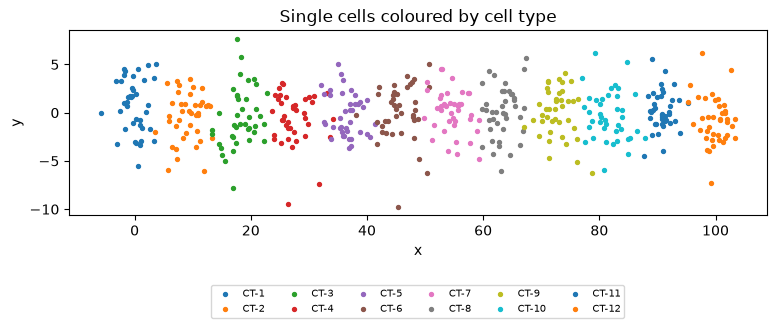

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.4))
for name in celltypes:
    mask = adata.obs['celltype'] == name
    ax.scatter(adata.obsm['spatial'][mask, 0], adata.obsm['spatial'][mask, 1], s=8, label=name)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Single cells coloured by cell type')
ax.legend(ncol=6, fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.35))
plt.show()

### Gene expression

Half of the ligand-receptor pairs are **informative**: the expression of their ligand and receptor
follows a bump centred somewhere along the axis, so cell types close to each other co-express them.
The other pairs are **noise**, with expression unrelated to position.

A perfect search would keep the informative pairs and drop the rest.

In [4]:
n_informative, n_noise = 12, 48

genes, profiles, pairs = [], [], []

for k in range(n_informative):
    centre = rng.uniform(0, 100)
    bump = 200 * np.exp(-((positions - centre) ** 2) / (2 * 22.0 ** 2))
    for tag in ('L', 'R'):
        genes.append('{}info{}'.format(tag, k))
        profiles.append(bump * rng.uniform(0.8, 1.2, n_celltypes))
    pairs.append(('Linfo{}'.format(k), 'Rinfo{}'.format(k)))

for k in range(n_noise):
    for tag in ('L', 'R'):
        genes.append('{}noise{}'.format(tag, k))
        profiles.append(rng.uniform(0, 200, n_celltypes))
    pairs.append(('Lnoise{}'.format(k), 'Rnoise{}'.format(k)))

rnaseq = pd.DataFrame(np.vstack(profiles), index=genes, columns=celltypes)
lr_pairs = pd.DataFrame(pairs, columns=['A', 'B'])

print('expression :', rnaseq.shape)
print('LR pairs   :', lr_pairs.shape[0], '({} informative, {} noise)'.format(n_informative, n_noise))
rnaseq.iloc[:4, :6].round(1)

expression : (120, 12)
LR pairs   : 60 (12 informative, 48 noise)


,CT-1,CT-2,CT-3,CT-4,CT-5,CT-6
Linfo0,162.9,222.6,171.7,124.8,108.6,64.2
Rinfo0,147.8,190.2,163.4,143.3,81.5,64.9
Linfo1,176.8,162.4,136.3,122.0,63.0,30.5
Rinfo1,199.9,162.7,189.7,115.6,69.1,31.4


## 2. Reference distances from the single-cell coordinates

`cell2cell.spatial.celltype_distances` summarizes the distance between two cell types from the
coordinates of their single cells. It takes an `AnnData` (reading `obsm`) or a plain dataframe, and
offers several ways to summarize:

| `method` | what it measures |
|---|---|
| `'centroid'` | distance between the centroids of the two cell types |
| `'min'` | how close the two types get to each other |
| `'max'` | how far apart their most distant cells are |
| `'mean'` / `'median'` | average / median over all pairs of their single cells |

Only `'centroid'` has a cost independent of how many single cells there are, so it is the one to
reach for on large datasets — the others evaluate all pairs of cells.

The key holding the coordinates is configurable with `spatial_key`, since objects written by
different tools use different ones (`'spatial'`, `'X_spatial'`, ...).

In [5]:
centroids = c2c.spatial.celltype_centroids(adata, group_col='celltype', spatial_key='spatial')
centroids.round(2).head()

,X,Y
celltype,,
CT-1,-0.15,0.75
CT-2,9.10,-0.42
CT-3,18.19,-0.53
CT-4,27.41,-0.61
CT-5,36.45,-0.19


In [6]:
for method in ['centroid', 'min', 'mean', 'median', 'max']:
    d = c2c.spatial.celltype_distances(adata, group_col='celltype', method=method)
    print('{:<9} CT-1 to CT-12 = {:6.2f}'.format(method, d.loc['CT-1', 'CT-12']))

centroid  CT-1 to CT-12 = 100.01
min       CT-1 to CT-12 =  91.64
mean      CT-1 to CT-12 = 100.08
median    CT-1 to CT-12 = 100.16
max       CT-1 to CT-12 = 109.19


In [7]:
reference_distances = c2c.spatial.celltype_distances(adata, group_col='celltype',
                                                     method='centroid')
reference_distances.iloc[:5, :5].round(1)

celltype,CT-1,CT-2,CT-3,CT-4,CT-5
celltype,,,,,
CT-1,0.0,9.3,18.4,27.6,36.6
CT-2,9.3,0.0,9.1,18.3,27.3
CT-3,18.4,9.1,0.0,9.2,18.3
CT-4,27.6,18.3,9.2,0.0,9.0
CT-5,36.6,27.3,18.3,9.0,0.0


## 3. The baseline: using every ligand-receptor pair

Before searching, we measure how well the CCI distances reproduce the reference when *all* pairs are
used. The genetic algorithm has to beat this.

The objective is the absolute **Spearman** correlation between the two distance matrices, in their
condensed (upper-triangle) form.

In [8]:
import scipy.spatial
from cell2cell.analysis.genetic_algorithm import PreparedCCIScorer, _bidirectional_index, _correlation
from cell2cell.core.interaction_space import InteractionSpace

analysis_setup = {'communication_score': 'expression_thresholding',
                  'cci_score': 'bray_curtis',
                  'cci_type': 'undirected'}
cutoff_setup = {'type': 'constant_value', 'parameter': 50}

bi_ppi = c2c.preprocessing.bidirectional_ppi_for_cci(lr_pairs, verbose=False)
interaction_space = InteractionSpace(rnaseq_data=rnaseq, ppi_data=bi_ppi,
                                     gene_cutoffs=cutoff_setup,
                                     communication_score=analysis_setup['communication_score'],
                                     cci_score=analysis_setup['cci_score'],
                                     cci_type=analysis_setup['cci_type'], verbose=False)

scorer = PreparedCCIScorer(interaction_space)
source = _bidirectional_index(lr_pairs, verbose=False)

reference_vector = scipy.spatial.distance.squareform(reference_distances.values, checks=False)
all_pairs = np.ones(len(lr_pairs))
baseline_distance = scorer.distance_batch(all_pairs[source][None, :])[0]
baseline = _correlation(scipy.spatial.distance.squareform(baseline_distance, checks=False),
                        reference_vector)

print('Spearman correlation using all {} pairs: {:.4f}'.format(len(lr_pairs), baseline))

Spearman correlation using all 60 pairs: 0.7459


## 4. Running the genetic algorithm

Each individual is a binary vector with one entry per ligand-receptor pair, saying whether it is
included. `optimize_lr_pairs` evolves a population of these and keeps the best.

The search happens in successive **runs**: each run keeps only the pairs the previous one selected,
so the set shrinks. With `runs=None` it stops once the objective improves by less than
`inc_percentage`.

In [9]:
results = c2c.analysis.optimize_lr_pairs(rnaseq_data=rnaseq,
                                         ppi_data=lr_pairs,
                                         reference_distances=reference_distances,
                                         cutoff_setup=cutoff_setup,
                                         analysis_setup=analysis_setup,
                                         population_size=60,
                                         generations=40,
                                         runs=3,
                                         random_state=888)

summary = pd.DataFrame([{'run': k,
                         'objective': results[k]['obj_fn'],
                         'pairs kept': results[k]['n_selected'],
                         'dropped': '{:.0%}'.format(results[k]['drop_fraction'])}
                        for k in sorted(results) if k.startswith('run')])
summary

,run,objective,pairs kept,dropped
0,run1,0.946273,21,65%
1,run2,0.961153,15,29%
2,run3,0.961968,9,40%


Every run improves on the baseline, and the set of pairs shrinks as it goes.

Because we know which pairs were informative, we can check *what* the search recovered.

In [10]:
for key in sorted(k for k in results if k.startswith('run')):
    kept = lr_pairs.loc[np.asarray(results[key]['ppi_data'], dtype=bool)]
    informative = kept['A'].str.startswith('Linfo').mean()
    print('{}: objective {:.4f} | {:>2} pairs kept | {:.0%} of them informative'
          .format(key, results[key]['obj_fn'], len(kept), informative))

best = results['best_ppi_data']
print('\nBest run:', results['best_run'], '-> objective {:.4f}'.format(results['best_obj_fn']))
best

run1: objective 0.9463 | 21 pairs kept | 48% of them informative
run2: objective 0.9612 | 15 pairs kept | 53% of them informative
run3: objective 0.9620 |  9 pairs kept | 78% of them informative

Best run: run3 -> objective 0.9620


,A,B
0,Linfo0,Rinfo0
1,Linfo1,Rinfo1
2,Linfo10,Rinfo10
3,Linfo11,Rinfo11
4,Linfo2,Rinfo2
5,Linfo6,Rinfo6
6,Linfo8,Rinfo8
7,Lnoise0,Rnoise0
8,Lnoise29,Rnoise29


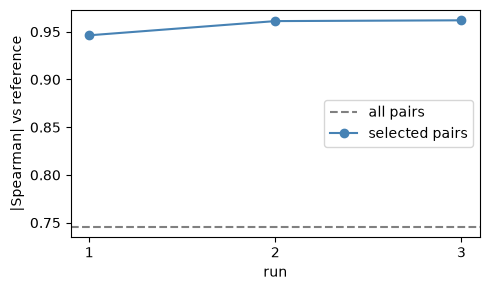

In [11]:
runs = sorted(k for k in results if k.startswith('run'))
objectives = [results[k]['obj_fn'] for k in runs]

fig, ax = plt.subplots(figsize=(5, 3))
ax.axhline(baseline, color='grey', ls='--', label='all pairs')
ax.plot(range(1, len(runs) + 1), objectives, 'o-', color='steelblue', label='selected pairs')
ax.set_xlabel('run'); ax.set_ylabel('|Spearman| vs reference')
ax.set_xticks(range(1, len(runs) + 1)); ax.legend()
plt.tight_layout(); plt.show()

### How the distances line up

Plotting the CCI distances against the reference shows what the search bought.

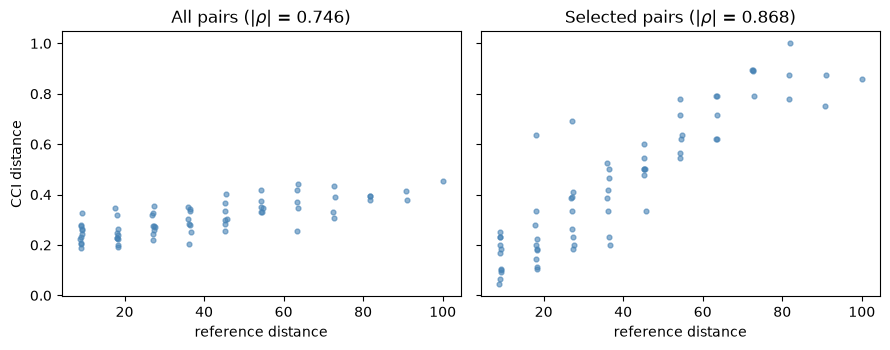

In [12]:
best_mask = np.zeros(len(lr_pairs))
best_mask[np.asarray(results[results['best_run']]['ppi_data'], dtype=bool)] = 1.0
best_distance = scorer.distance_batch(best_mask[source][None, :])[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
for ax, matrix, title in zip(axes, [baseline_distance, best_distance],
                             ['All pairs', 'Selected pairs']):
    vector = scipy.spatial.distance.squareform(matrix, checks=False)
    rho = _correlation(vector, reference_vector)
    ax.scatter(reference_vector, vector, s=12, alpha=0.6, color='steelblue')
    ax.set_title('{} ($|\\rho|$ = {:.3f})'.format(title, rho))
    ax.set_xlabel('reference distance')
axes[0].set_ylabel('CCI distance')
plt.tight_layout(); plt.show()

## 5. Why this is fast

Rebuilding the CCI scores for every individual would be far too slow: the published analysis used a
population of 200 over 200 generations, i.e. **40,000 evaluations per run**.

`PreparedCCIScorer` avoids that. Every CCI score is a function of three quantities that are each a
weighted sum over the ligand-receptor pairs, and therefore **linear in the pair weights** `w`:

```
N(i, j) = sum_k w_k * A_ki * B_kj        SA(i) = sum_k w_k * A_ki^2
                                         SB(j) = sum_k w_k * B_kj^2

bray_curtis = 2N / (SA + SB)      jaccard = N / (SA + SB - N)      icellnet = N
```

`A` and `B` depend only on the expression data, which does not change during the search. So they are
computed once, and scoring a whole population becomes a single matrix multiplication.

This is used automatically. `fast=False` falls back to rebuilding the scores through
`InteractionSpace`, exactly as the original implementation did — the two give the same answer.

In [13]:
import time

rng_check = np.random.default_rng(0)
population = rng_check.integers(0, 2, size=(200, len(lr_pairs))).astype(float)

start = time.perf_counter()
batched = scorer.score_batch(population[:, source])
t_batched = time.perf_counter() - start

start = time.perf_counter()
one_at_a_time = np.stack([scorer.score_batch(w[source][None, :])[0] for w in population])
t_single = time.perf_counter() - start

print('whole population at once : {:.4f} s'.format(t_batched))
print('one individual at a time : {:.4f} s'.format(t_single))
print('identical                :', np.allclose(batched, one_at_a_time, rtol=1e-12, atol=1e-12))

whole population at once : 0.0004 s
one individual at a time : 0.0045 s
identical                : True


In [14]:
# ...and the vectorized scorer agrees with the reference implementation
theta = rng_check.integers(0, 2, size=len(lr_pairs)).astype(float)
weights = theta[source]

interaction_space.ppi_data['score'] = weights
interaction_space.compute_pairwise_cci_scores(use_ppi_score=True, verbose=False)
expected = interaction_space.interaction_elements['cci_matrix'].values

print('largest difference vs InteractionSpace: {:.2e}'
      .format(np.abs(scorer.score_batch(weights[None, :])[0] - expected).max()))

largest difference vs InteractionSpace: 0.00e+00


## 6. The *C. elegans* analysis

The published study searched for the ligand-receptor pairs that best explain the physical distances
between the cells of the whole animal. The data is in
[LewisLabUCSD/Celegans-cell2cell](https://github.com/LewisLabUCSD/Celegans-cell2cell), and pandas
reads it straight from the URL, so everything below runs as it is.

In [15]:
BASE = ('https://raw.githubusercontent.com/LewisLabUCSD/'
        'Celegans-cell2cell/master/data/')

celegans_rnaseq = c2c.io.load_rnaseq(
    rnaseq_file=BASE + 'RNA-Seq/Celegans_RNASeqData_Cell.xlsx',
    gene_column='gene_id', drop_nangenes=True, log_transformation=False,
    format='auto', verbose=False)

celegans_lr = c2c.io.load_ppi(
    ppi_file=BASE + 'PPI-Networks/Celegans-Curated-LR-pairs.xlsx',
    interaction_columns=('Ligand_WB', 'Receptor_WB'),
    rnaseq_genes=list(celegans_rnaseq.index), format='auto', verbose=False)

physical_distances = pd.read_csv(
    BASE + 'Digital-3D-Map/Celegans_Physical_Distances_Min.csv', index_col=0)

print('expression      :', celegans_rnaseq.shape, '(genes x cells)')
print('LR pairs        :', len(celegans_lr))
print('cells in the map:', physical_distances.shape[0])

expression      : (19391, 27) (genes x cells)
LR pairs        : 245
cells in the map: 22


The study reported three variants, differing only in the score:

| Score | `communication_score` | `cci_score` | Notes |
|---|---|---|---|
| Bray-Curtis | `expression_thresholding` | `bray_curtis` | the main analysis |
| LR count | `expression_thresholding` | `count` | counts active pairs |
| ICELLNET | `expression_product` | `icellnet` | expression is `log2(x + 1)` transformed first |

We run the Bray-Curtis one, at the published settings: 200 individuals, 200 generations, a 10 TPM
threshold, and runs continuing until the objective improves by less than 2.5%.

In [16]:
celegans_setup = {'communication_score': 'expression_thresholding',
                  'cci_score': 'bray_curtis',
                  'cci_type': 'undirected'}

start = time.perf_counter()
celegans_results = c2c.analysis.optimize_lr_pairs(
    rnaseq_data=celegans_rnaseq,
    ppi_data=celegans_lr,
    reference_distances=physical_distances,
    cutoff_setup={'type': 'constant_value', 'parameter': 10},   # 10 TPM
    analysis_setup=celegans_setup,
    population_size=200,
    generations=200,
    runs=None,                 # until the objective stops improving
    inc_percentage=0.025,
    random_state=888,
)
print('finished in {:.0f} s'.format(time.perf_counter() - start))

pd.DataFrame([{'run': k, 'objective': celegans_results[k]['obj_fn'],
               'pairs kept': celegans_results[k]['n_selected']}
              for k in sorted(celegans_results) if k.startswith('run')])

finished in 28 s


,run,objective,pairs kept
0,run1,0.498713,91
1,run2,0.623005,45
2,run3,0.642090,30
3,run4,0.647806,23


Each of the ~40,000 objective evaluations per run would otherwise have meant rebuilding the CCI
scores; the vectorized scorer is what brings the whole search down to seconds.

### Comparing with the pairs published in the paper

The 37 pairs the paper selected for Bray-Curtis are in the same repository.

In [17]:
paper_pairs = pd.read_csv(BASE + 'PPI-Networks/Celegans-GA-BrayCurtis-Selected-LR-pairs.csv')

# `remove_ppi_bidirectionality` can flip a pair, so compare them as unordered
unordered = lambda a, b: frozenset((a, b))
paper_keys = {unordered(a, b) for a, b in
              paper_pairs[['Ligand_WB', 'Receptor_WB']].values}
our_keys = {unordered(a, b) for a, b in
            celegans_results['best_ppi_data'][['A', 'B']].values}

shared = our_keys & paper_keys
print('paper selection      : {} pairs'.format(len(paper_keys)))
print('our selection        : {} pairs'.format(len(our_keys)))
print('  also in the paper  : {}'.format(len(shared)))
print('  not in the paper   : {}'.format(len(our_keys - paper_keys)))
print('  of the paper\'s, we recovered {} ({:.0%})'
      .format(len(shared), len(shared) / len(paper_keys)))

paper selection      : 37 pairs
our selection        : 23 pairs
  also in the paper  : 21
  not in the paper   : 2
  of the paper's, we recovered 21 (57%)


The overlap is far beyond chance, but a single execution understates the agreement: a genetic
algorithm returns a *local* optimum, so different seeds land on different, largely overlapping sets.

The published analysis handled this by running the search many times independently and asking which
pairs are selected **together**. `executions=N` does that here — it repeats the search and adds three
things to the result:

- `selection_frequency` — how often each pair was chosen;
- `cooccurrence` — the Jaccard index between the selection patterns of every two pairs, i.e. how
  often they are chosen alongside each other;
- `consensus_ppi_data` — the pairs of the co-occurrence cluster whose members are most consistently
  co-selected. **This is the output to use.**

In [18]:
start = time.perf_counter()
consensus = c2c.analysis.optimize_lr_pairs(
    rnaseq_data=celegans_rnaseq,
    ppi_data=celegans_lr,
    reference_distances=physical_distances,
    cutoff_setup={'type': 'constant_value', 'parameter': 10},
    analysis_setup=celegans_setup,
    population_size=200, generations=200, runs=None, inc_percentage=0.025,
    executions=30,             # thirty independent searches
    random_state=888,
)
print('30 executions in {:.0f} s'.format(time.perf_counter() - start))

consensus['selection_frequency'].head(10)

30 executions in 765 s


,A,B,frequency
23,WBGene00000857,WBGene00003238,1.000000
189,WBGene00004890,WBGene00004047,0.966667
173,WBGene00003774,WBGene00011345,0.933333
235,WBGene00019407,WBGene00011345,0.933333
16,WBGene00000674,WBGene00016104,0.800000
143,WBGene00002881,WBGene00006894,0.766667
11,WBGene00000527,WBGene00001687,0.733333
224,WBGene00006951,WBGene00004208,0.700000
156,WBGene00003111,WBGene00004048,0.700000
46,WBGene00000936,WBGene00020649,0.666667


The co-occurrence matrix is what the consensus is built from. Clustering it separates a tight group
of pairs that keep being chosen together from a diffuse remainder.

In [19]:
sizes = {k: len(v) for k, v in consensus['consensus_clusters'].items()}
scores = {k: round(v, 3) for k, v in consensus['consensus_cluster_scores'].items()}
print('cluster sizes             :', sizes)
print('mean co-occurrence within :', scores)
print('\nconsensus selection: {} pairs'.format(len(consensus['consensus_ppi_data'])))

cluster sizes             : {np.int32(1): 75, np.int32(2): 31}
mean co-occurrence within : {np.int32(1): 0.076, np.int32(2): 0.359}

consensus selection: 31 pairs


In [20]:
consensus_keys = {unordered(a, b) for a, b in consensus['consensus_ppi_data'][['A', 'B']].values}
shared = consensus_keys & paper_keys
print('consensus selection  : {} pairs'.format(len(consensus_keys)))
print('  also in the paper  : {}'.format(len(shared)))
print('  not in the paper   : {}'.format(len(consensus_keys - paper_keys)))

consensus selection  : 31 pairs
  also in the paper  : 29
  not in the paper   : 2


The two criteria for *which* cluster to keep coincide on this data: the tight cluster is also the
smaller one. `cluster_selection='cooccurrence'` (the default) ranks by mean co-occurrence among a
cluster's own members, which is the property the analysis is actually after;
`cluster_selection='smallest'` is literally what the reference notebook did and is kept so the
published result can be reproduced exactly.

> **How many executions?** The clustering needs enough of them. Two pairs selected once, in the same
> execution, have a co-occurrence of 1.0 without that meaning anything, and with too few executions a
> cluster of such pairs outscores the reproducible one — with 10 executions this analysis returns 17
> pairs of which only 6 are the paper's, against 29 of 31 with 30. Use around 30 or more (the
> reference analysis used about a hundred), or set `min_frequency` to drop the rarely-chosen pairs.
> The frequency route below is the more forgiving of the two.

### The simpler alternative: selection frequency

Rather than asking which pairs are chosen *together*, one can just keep those chosen *often*. The
reference notebook computed this too, using the 90th percentile of the frequency distribution. It is
easier to reason about, but it cannot separate two groups of pairs that are each self-consistent yet
rarely co-selected.

In [21]:
frequency = consensus['selection_frequency']['frequency'].values

for percentile in (80, 85, 90, 95):
    mask, threshold = c2c.analysis.consensus_from_frequency(frequency, percentile=percentile)
    kept = consensus['selection_frequency'].loc[mask]
    keys = {unordered(a, b) for a, b in kept[['A', 'B']].values}
    print('{}th percentile (frequency > {:.2f}): {:>2} pairs | {:>2} in the paper, {:>2} not'
          .format(percentile, threshold, len(keys), len(keys & paper_keys),
                  len(keys - paper_keys)))

80th percentile (frequency > 0.17): 41 pairs | 34 in the paper,  7 not
85th percentile (frequency > 0.20): 35 pairs | 33 in the paper,  2 not
90th percentile (frequency > 0.33): 24 pairs | 24 in the paper,  0 not
95th percentile (frequency > 0.56): 13 pairs | 13 in the paper,  0 not


Both routes converge on the same set of pairs — the ones the paper reports. Which to prefer depends
on the question: the co-occurrence clustering keeps groups of pairs that act together, while the
frequency threshold is a plain ranking of individual pairs.

The same steps are available on their own, for integrating results computed elsewhere:
`c2c.analysis.lr_selection_frequency`, `lr_cooccurrence`, `consensus_from_cooccurrence` and
`consensus_from_frequency`.

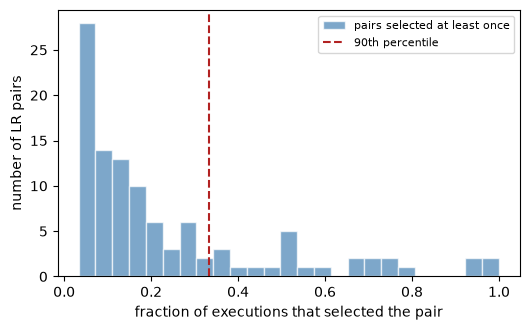

In [22]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.hist(frequency[frequency > 0], bins=25, color='steelblue', alpha=0.7,
        edgecolor='w', label='pairs selected at least once')
_, threshold = c2c.analysis.consensus_from_frequency(frequency, percentile=90)
ax.axvline(threshold, color='firebrick', ls='--', label='90th percentile')
ax.set_xlabel('fraction of executions that selected the pair')
ax.set_ylabel('number of LR pairs'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Notes

- **`pygad` is not `pyevolve`**, the seeds differ, and the published set is one run of many, so the
  numbers will not match exactly. The reproducible core is what should agree, and does.
- **The pair list is deduplicated first.** `optimize_lr_pairs` applies `remove_ppi_bidirectionality`
  before searching (`deduplicate=True`), because `bidirectional_ppi_for_cci` drops duplicates on
  (A, B, score): if a table holds a pair *and* its reciprocal, the number of bidirectional rows
  depends on the candidate solution and a pair no longer maps onto a fixed set of them. Pairs loaded
  with `load_ppi` are already deduplicated, so this is a no-op here.
- **No multiprocessing.** The original distributed independent runs across cores; the vectorized
  objective makes one run fast enough that it is not needed.